<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/Taller_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 1
* Implement a classification model to predict mango leaf disease
* Create a HOG feature vector
* Use the classifier of your choice (Neural Networks, Decision Trees, KNN, SVM)
* Evaluate (Accuracy – F1 score)

In [ ]:
# IMPORTS
import os
from pathlib import Path
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CONFIGURACIÓN
DATA_DIR = "/content/drive/MyDrive/Doctorado/Cursos/Vision_computador_aplicado/Taller_1/mango_leaf_disease/mango_leaf_disease"  # <-- CAMBIA esta ruta a tu carpeta raíz del dataset
IMG_SIZE = (128, 128)                             # tamaño fijo para todas las imágenes (rápido y suficiente para HOG)
RANDOM_STATE = 42

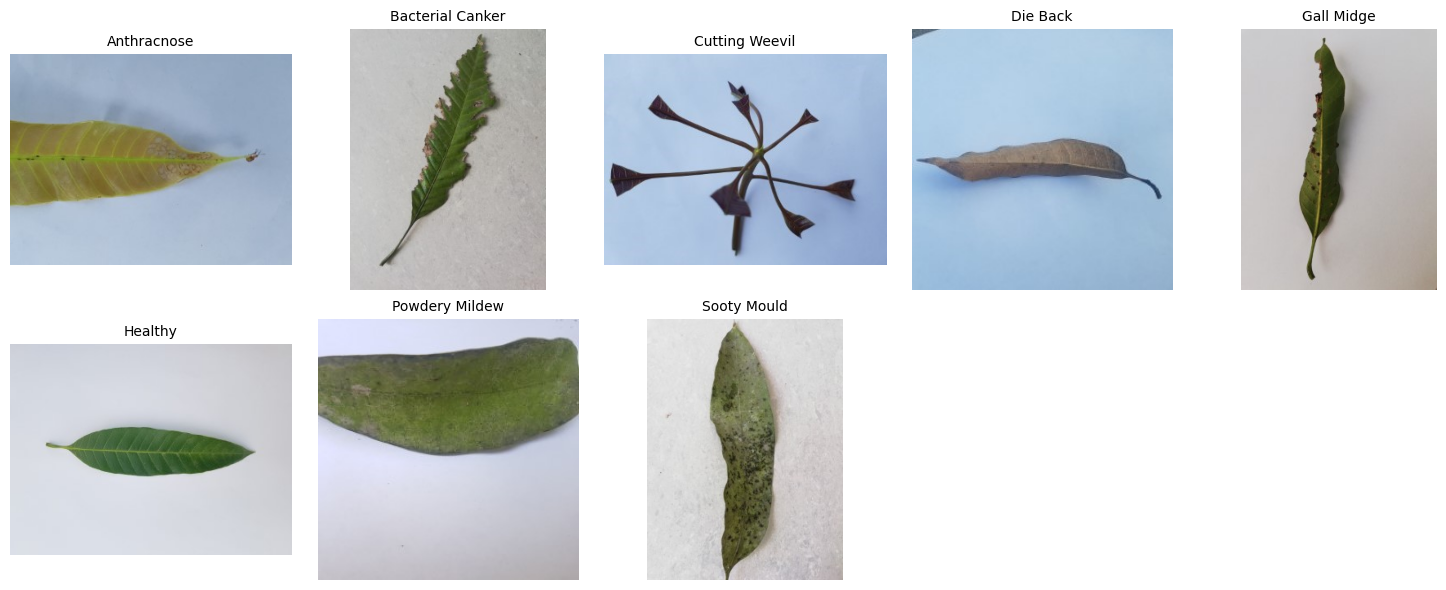

In [ ]:
# Recolecta una sola imagen por clase
data_path = Path(DATA_DIR)
class_dirs = sorted([p for p in data_path.iterdir() if p.is_dir()])

samples = []
exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

for cdir in class_dirs:
    files = []
    for ext in exts:
        files += sorted(cdir.glob(ext))
    if not files:
        print(f"Sin imágenes en: {cdir.name}")
        continue
    img = imread(files[0])
    samples.append((cdir.name, img))

if not samples:
    raise RuntimeError("No se encontró ninguna imagen en las carpetas de clases.")

# Calcula layout del grid (filas x columnas)
n = len(samples)
cols = min(n, 5)
rows = math.ceil(n / cols)

#  Dibuja el grid: una imagen por clase
plt.figure(figsize=(cols * 3, rows * 3))
for i, (label, img) in enumerate(samples, start=1):
    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# FUNCIÓN: extraer HOG de una imagen
def hog_features(img_path, img_size=IMG_SIZE):
    img = imread(img_path)
    if img.ndim == 3:
        img = rgb2gray(img)
    img_resized = resize(img, img_size, anti_aliasing=True)
    feat = hog(
        img_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )
    return feat

In [ ]:
# CARGA: recorre subcarpetas y genera X (HOG) e y (etiquetas)
def load_dataset_hog(data_dir):
    X, y = [], []
    data_path = Path(data_dir)
    classes = sorted([p.name for p in data_path.iterdir() if p.is_dir()])
    if not classes:
        raise ValueError("No se encontraron subcarpetas de clases dentro de DATA_DIR.")

    for cls in classes:
        for img_file in (data_path/cls).glob("*.*"):
            try:
                X.append(hog_features(img_file))
                y.append(cls)
            except Exception as e:
                print(f"Saltando {img_file} por error: {e}")
    return np.array(X), np.array(y), classes


In [ ]:
# CARGAR DATOS Y DIVIDIR
X, y, class_names = load_dataset_hog(DATA_DIR)
print("Clases:", class_names)
print("Shape X:", X.shape, "| #ejemplos:", len(y))


Clases: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Shape X: (4000, 8100) | #ejemplos: 4000


In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

In [ ]:
# MODELO: HOG + ESCALADO + SVM LINEAL
clf = make_pipeline(
    StandardScaler(),
    LinearSVC(class_weight="balanced",
              random_state=RANDOM_STATE,
              max_iter=20)
)

clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(class_weight='balanced', max_iter=1,
                           random_state=42))])

In [ ]:
# EVALUACIÓN: accuracy y F1
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f}")

# Reporte detallado por clase (precisión, recall, F1)
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, target_names=le.inverse_transform(sorted(set(y_test)))))

Accuracy: 0.6188 | F1-macro: 0.6106

Reporte por clase:
                  precision    recall  f1-score   support

     Anthracnose       0.45      0.40      0.42       100
Bacterial Canker       0.69      0.72      0.70       100
  Cutting Weevil       0.74      0.95      0.83       100
        Die Back       0.73      0.78      0.75       100
      Gall Midge       0.44      0.39      0.41       100
         Healthy       0.69      0.68      0.69       100
  Powdery Mildew       0.66      0.61      0.64       100
     Sooty Mould       0.45      0.42      0.44       100

        accuracy                           0.62       800
       macro avg       0.61      0.62      0.61       800
    weighted avg       0.61      0.62      0.61       800



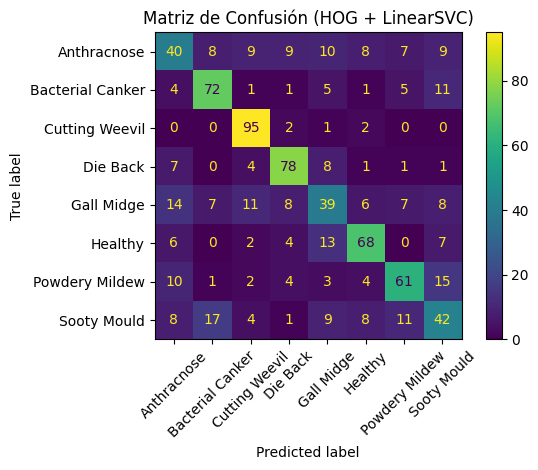

In [ ]:
# MATRIZ DE CONFUSIÓN
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_, cmap=None, xticks_rotation=45
)
plt.title("Matriz de Confusión (HOG + LinearSVC)")
plt.tight_layout()
plt.show()

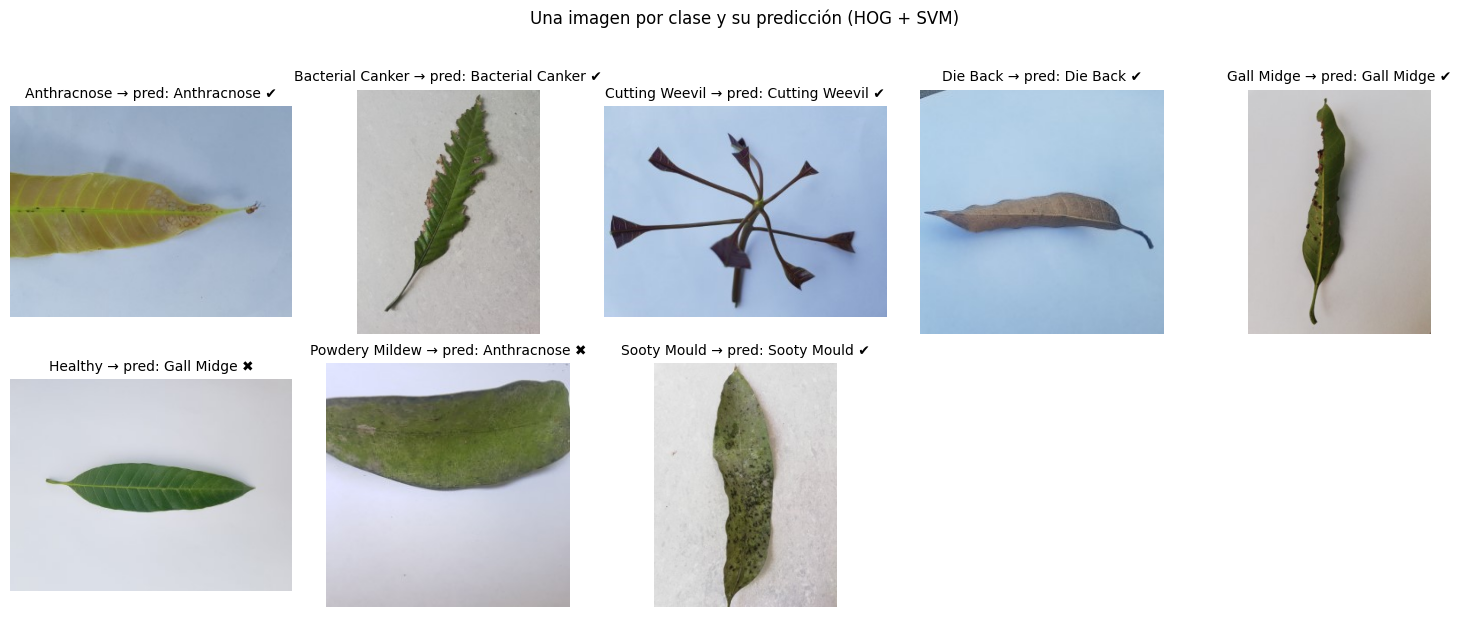

In [ ]:
samples = []
for cdir in class_dirs:
    files = []
    for ext in exts:
        files += sorted(cdir.glob(ext))
    if not files:
        print(f"Sin imágenes en: {cdir.name}")
        continue

    img_path = files[0]
    img = imread(img_path)
    feat = hog_features(img_path)
    pred_idx = clf.predict([feat])[0]
    pred_label = le.inverse_transform([pred_idx])[0]

    samples.append((cdir.name, pred_label, img))

if not samples:
    raise RuntimeError("No se encontró ninguna imagen en las carpetas de clases.")

# Plot: grid con una imagen por clase y su predicción
n = len(samples)
cols = min(n, 5)
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 3, rows * 3))
for i, (true_label, pred_label, img) in enumerate(samples, start=1):
    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ok = "✔️" if pred_label == true_label else "✖️"
    ax.set_title(f"{true_label} → pred: {pred_label} {ok}", fontsize=10)
    ax.axis("off")

plt.suptitle("Una imagen por clase y su predicción (HOG + SVM)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()